# Stress Testing: WNBA Salary Valuation Models

1. Load processed train/test artifacts from `data/processed/`
2. Fit baseline models on 2021–2024 training data
3. Run stress tests:
   - **Test 1: Noise Injection** : Add Gaussian noise to numeric features; measure prediction stability
   - **Test 2: Extreme Stat Inputs** : Feed players with 1st and 99th percentile stats; check for nonsensical predictions
   - **Test 3: Contract Group Robustness** : Evaluate per-group (rookie / hardship / veteran / other) to diagnose where models break down
4. Log all results to `results/stress_test_log.csv`

## Imports and Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

NOISE_LEVELS = [0.01, 0.05, 0.10, 0.20]  # Fractions of feature std to inject as noise
N_NOISE_TRIALS = 30                        # Repeat each noise level N times for stability
RANDOM_SEED = 42

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent

processed_dir = repo / "data" / "processed"
results_dir = repo / "results"
results_dir.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## 1. Load Processed Data

In [2]:
X_train = pd.read_csv(processed_dir / "X_train_processed.csv")
y_train = pd.read_csv(processed_dir / "y_train.csv")["salary"]
X_test  = pd.read_csv(processed_dir / "X_test_2025_processed.csv")
y_test  = pd.read_csv(processed_dir / "y_test_2025.csv")["salary"]
lookup_test  = pd.read_csv(processed_dir / "player_lookup_test_2025.csv")
feature_names = pd.read_csv(processed_dir / "feature_names.csv")["feature"].tolist()

# Identify numeric features only (OHE columns are binary — skip them for noise/extreme tests)
ohe_cols  = [c for c in feature_names if c.startswith("group_")]
num_cols  = [c for c in feature_names if c not in ohe_cols]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Numeric features: {len(num_cols)}, OHE features: {len(ohe_cols)}")

X_train: (742, 22), X_test: (223, 22)
Numeric features: 17, OHE features: 5


## 2. Fit Baseline Models on Training Data

Same model set as `evaluation_result.ipynb`. Fit once on 2021–2024; reuse across all stress tests.

In [3]:
models = {
    "DummyRegressor":        DummyRegressor(strategy="mean"),
    "LinearRegression":      LinearRegression(),
    "Ridge":                 Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5, random_state=26
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    holdout_rmse = root_mean_squared_error(y_test, model.predict(X_test))
    print(f"{name}: holdout RMSE = ${holdout_rmse:,.0f}")

DummyRegressor: holdout RMSE = $68,540
LinearRegression: holdout RMSE = $45,158
Ridge: holdout RMSE = $44,798
RandomForestRegressor: holdout RMSE = $41,616


## 3. Stress Test 1: Noise Injection

**What we are checking:** Do salary predictions stay stable when we add small random perturbations to the input features?

A robust model should produce predictions that shift proportionally to the noise level. Wild swings at low noise levels (1–5%) would indicate fragility.

**Method:** For each noise level, add Gaussian noise scaled to that fraction of each feature's standard deviation. Repeat 30 trials per level and record the mean absolute shift in predicted salary versus the clean baseline.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
feature_stds = X_test[num_cols].std()

noise_rows = []

for model_name, model in models.items():
    baseline_preds = model.predict(X_test)

    for noise_level in NOISE_LEVELS:
        trial_shifts = []

        for _ in range(N_NOISE_TRIALS):
            X_noisy = X_test.copy()
            noise = rng.normal(
                loc=0,
                scale=(feature_stds * noise_level).values,
                size=(len(X_test), len(num_cols)),
            )
            X_noisy[num_cols] += noise

            noisy_preds = model.predict(X_noisy)
            mean_shift = np.abs(noisy_preds - baseline_preds).mean()
            trial_shifts.append(mean_shift)

        noise_rows.append({
            "test_name":         "noise_injection",
            "model":             model_name,
            "noise_level_pct":   noise_level * 100,
            "n_trials":          N_NOISE_TRIALS,
            "mean_pred_shift":   np.mean(trial_shifts),
            "max_pred_shift":    np.max(trial_shifts),
            "std_pred_shift":    np.std(trial_shifts),
            "generated_at":      pd.Timestamp.now().isoformat(timespec="seconds"),
        })

noise_df = pd.DataFrame(noise_rows)
display(noise_df)

,test_name,model,noise_level_pct,n_trials,mean_pred_shift,max_pred_shift,std_pred_shift,generated_at
0,noise_injection,DummyRegressor,1.0,30,0.000000,0.000000,0.000000,2026-06-18T22:01:38
1,noise_injection,DummyRegressor,5.0,30,0.000000,0.000000,0.000000,2026-06-18T22:01:38
2,noise_injection,DummyRegressor,10.0,30,0.000000,0.000000,0.000000,2026-06-18T22:01:38
3,noise_injection,DummyRegressor,20.0,30,0.000000,0.000000,0.000000,2026-06-18T22:01:38
4,noise_injection,LinearRegression,1.0,30,869.699613,950.860659,46.543347,2026-06-18T22:01:38
5,noise_injection,LinearRegression,5.0,30,4298.700665,4827.628985,213.145932,2026-06-18T22:01:38
6,noise_injection,LinearRegression,10.0,30,8747.718380,9400.146352,313.351717,2026-06-18T22:01:38
7,noise_injection,LinearRegression,20.0,30,17375.818034,19500.059473,842.251351,2026-06-18T22:01:38
8,noise_injection,Ridge,1.0,30,726.662721,798.848986,38.183088,2026-06-18T22:01:39
9,noise_injection,Ridge,5.0,30,3641.114216,3919.195646,165.398904,2026-06-18T22:01:39


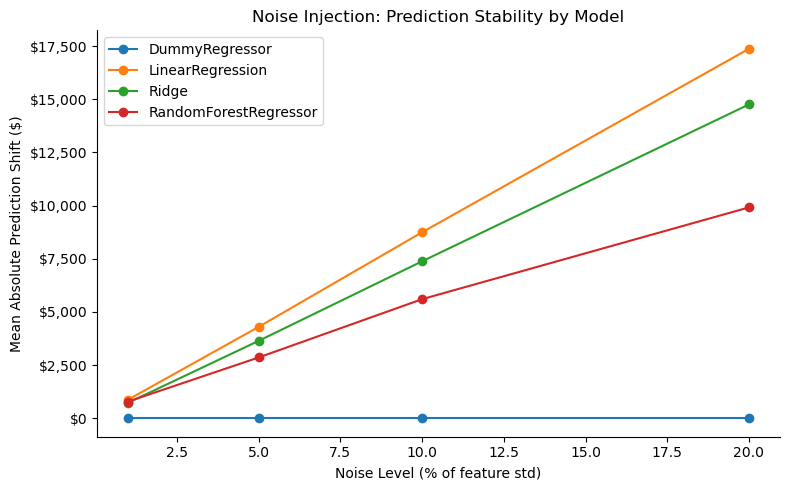

In [5]:
# Plot: mean prediction shift vs. noise level, one line per model
fig, ax = plt.subplots(figsize=(8, 5))

for model_name in models:
    subset = noise_df[noise_df["model"] == model_name]
    ax.plot(
        subset["noise_level_pct"],
        subset["mean_pred_shift"],
        marker="o",
        label=model_name,
    )

ax.set_xlabel("Noise Level (% of feature std)")
ax.set_ylabel("Mean Absolute Prediction Shift ($)")
ax.set_title("Noise Injection: Prediction Stability by Model")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

## 4. Stress Test 2: Extreme Stat Inputs

**What we are checking:** Does the model produce sensible salary predictions for extreme players — someone with all stats at the 1st percentile (fringe player) or all at the 99th (superstar)?

We also construct a mixed-extreme row where offensive stats are maxed out but efficiency stats are minimal, to check for illogical combinations.

**What counts as sensible:** Predictions should be within or near the observed salary range in the training data (~$7k–$250k). Predictions below zero or above ~$500k are flagged.

In [6]:
# Build extreme rows using train distribution (not test, we don't want to peek at 2025)
p01 = X_train[num_cols].quantile(0.01)
p99 = X_train[num_cols].quantile(0.99)

# For OHE group columns, use a neutral "other" encoding (all zeros, unknown group catches this)
ohe_neutral = pd.Series(0, index=ohe_cols)

def make_extreme_row(num_vals, label):
    row = pd.concat([num_vals, ohe_neutral])
    return row.reindex(feature_names).to_frame().T.reset_index(drop=True), label

# Mixed extreme: high volume, low efficiency
mixed = p99.copy()
for col in ["avail_rate", "start_rate"]:
    if col in mixed.index:
        mixed[col] = p01[col]

extreme_inputs = [
    make_extreme_row(p01, "p01_all_features"),
    make_extreme_row(p99, "p99_all_features"),
    make_extreme_row(mixed, "p99_volume_p01_availability"),
]

# Salary bounds observed in training data
salary_min = y_train.min()
salary_max = y_train.max()
extreme_rows = []

for X_extreme, label in extreme_inputs:
    for model_name, model in models.items():
        pred = model.predict(X_extreme)[0]
        in_range = salary_min <= pred <= salary_max * 2  # Allow 2x max as generous upper bound
        extreme_rows.append({
            "test_name":          "extreme_stat_inputs",
            "model":              model_name,
            "input_profile":      label,
            "predicted_salary":   pred,
            "train_salary_min":   salary_min,
            "train_salary_max":   salary_max,
            "within_range":       in_range,
            "generated_at":       pd.Timestamp.now().isoformat(timespec="seconds"),
        })

extreme_df = pd.DataFrame(extreme_rows)
extreme_df["predicted_salary"] = extreme_df["predicted_salary"].map("${:,.0f}".format)
display(extreme_df)

,test_name,model,input_profile,predicted_salary,train_salary_min,train_salary_max,within_range,generated_at
0,extreme_stat_inputs,DummyRegressor,p01_all_features,"$87,598",464,242154,True,2026-06-18T22:01:40
1,extreme_stat_inputs,LinearRegression,p01_all_features,"$18,215",464,242154,True,2026-06-18T22:01:40
2,extreme_stat_inputs,Ridge,p01_all_features,"$19,091",464,242154,True,2026-06-18T22:01:40
3,extreme_stat_inputs,RandomForestRegressor,p01_all_features,"$30,993",464,242154,True,2026-06-18T22:01:40
4,extreme_stat_inputs,DummyRegressor,p99_all_features,"$87,598",464,242154,True,2026-06-18T22:01:40
5,extreme_stat_inputs,LinearRegression,p99_all_features,"$151,928",464,242154,True,2026-06-18T22:01:40
6,extreme_stat_inputs,Ridge,p99_all_features,"$153,905",464,242154,True,2026-06-18T22:01:40
7,extreme_stat_inputs,RandomForestRegressor,p99_all_features,"$186,085",464,242154,True,2026-06-18T22:01:40
8,extreme_stat_inputs,DummyRegressor,p99_volume_p01_availability,"$87,598",464,242154,True,2026-06-18T22:01:40
9,extreme_stat_inputs,LinearRegression,p99_volume_p01_availability,"$133,057",464,242154,True,2026-06-18T22:01:40


## 5. Stress Test 3: Contract Group Robustness

**What we are checking:** Does model performance degrade significantly for specific contract groups?

We know from `KPI_baseline.ipynb` that MAPE blows up on rookie and hardship contracts. This test measures RMSE and MAE per group on the 2025 holdout to confirm which groups each model handles well and which it fails on.

This is important context for the written summary: a model may look good overall while being badly miscalibrated for a specific tier.

In [7]:
group_rows = []

for model_name, model in models.items():
    preds = model.predict(X_test)
    results_with_group = lookup_test.copy()
    results_with_group["predicted_salary"] = preds
    results_with_group["actual_salary"] = y_test.values

    for group, grp_df in results_with_group.groupby("group"):
        if len(grp_df) < 2:
            continue  # Skip groups too small for meaningful metrics

        rmse = root_mean_squared_error(grp_df["actual_salary"], grp_df["predicted_salary"])
        mae  = mean_absolute_error(grp_df["actual_salary"], grp_df["predicted_salary"])
        median_actual = grp_df["actual_salary"].median()

        group_rows.append({
            "test_name":        "contract_group_robustness",
            "model":            model_name,
            "group":            group,
            "n_players":        len(grp_df),
            "rmse":             rmse,
            "mae":              mae,
            "median_actual":    median_actual,
            "mae_as_pct_median": mae / median_actual * 100 if median_actual > 0 else np.nan,
            "generated_at":     pd.Timestamp.now().isoformat(timespec="seconds"),
        })

group_df = pd.DataFrame(group_rows)
display(group_df.sort_values(["model", "rmse"], ascending=[True, False]))

,test_name,model,group,n_players,rmse,mae,median_actual,mae_as_pct_median,generated_at
4,contract_group_robustness,DummyRegressor,veteran,133,76888.917419,65833.998977,78831.0,83.512830,2026-06-18T22:01:40
1,contract_group_robustness,DummyRegressor,hardship,20,75081.961777,70234.921833,6630.5,1059.270369,2026-06-18T22:01:40
3,contract_group_robustness,DummyRegressor,unknown,17,73061.574299,53701.268987,78066.0,68.789574,2026-06-18T22:01:40
0,contract_group_robustness,DummyRegressor,controlled,13,45819.405721,35060.355484,66079.0,53.058242,2026-06-18T22:01:40
2,contract_group_robustness,DummyRegressor,rookie,40,27622.394647,17225.168194,75276.0,22.882683,2026-06-18T22:01:40
9,contract_group_robustness,LinearRegression,veteran,133,51649.567646,41533.349534,78831.0,52.686569,2026-06-18T22:01:40
8,contract_group_robustness,LinearRegression,unknown,17,49049.296670,43810.670926,78066.0,56.120041,2026-06-18T22:01:40
5,contract_group_robustness,LinearRegression,controlled,13,35320.858685,27509.787019,66079.0,41.631664,2026-06-18T22:01:40
6,contract_group_robustness,LinearRegression,hardship,20,33870.523837,27758.413722,6630.5,418.647368,2026-06-18T22:01:40
7,contract_group_robustness,LinearRegression,rookie,40,22299.889566,15413.539270,75276.0,20.476034,2026-06-18T22:01:40


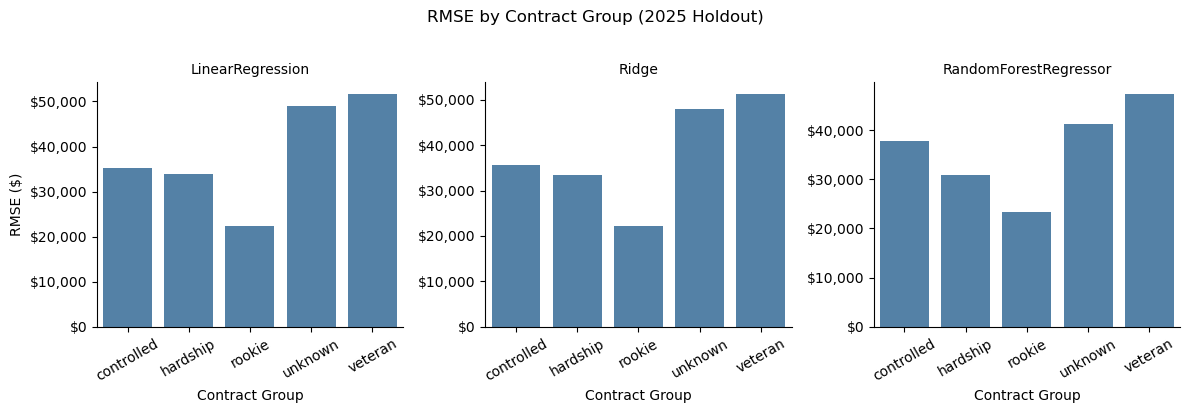

In [8]:
# Plot: RMSE by contract group, faceted by model
plot_df = group_df[group_df["model"] != "DummyRegressor"].copy()

g = sns.FacetGrid(plot_df, col="model", col_wrap=3, height=4, sharey=False)
g.map_dataframe(
    sns.barplot,
    x="group",
    y="rmse",
    order=sorted(plot_df["group"].unique()),
    color="steelblue",
)
g.set_axis_labels("Contract Group", "RMSE ($)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    for label in ax.get_xticklabels():
        label.set_rotation(30)
g.figure.suptitle("RMSE by Contract Group (2025 Holdout)", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

## 6. Save Stress Test Log

All results are combined into a single log file saved to `results/stress_test_log.csv`.
Each row includes a `test_name` column so results can be filtered by test type downstream.

In [9]:
# Normalize extreme_df before concat (undo the formatting applied for display)
extreme_df_raw = pd.DataFrame(extreme_rows)  # Re-use the unformatted version

log = pd.concat(
    [noise_df, extreme_df_raw, group_df],
    ignore_index=True,
    sort=False,
)

log_path = results_dir / "stress_test_log.csv"
log.to_csv(log_path, index=False)

print(f"Stress test log saved: {log_path}")
print(f"Total rows logged: {len(log)}")
print(f"Tests covered: {log['test_name'].unique().tolist()}")

Stress test log saved: /Users/aklima/GitHub/summer26-wnba-player-valuation/results/stress_test_log.csv
Total rows logged: 48
Tests covered: ['noise_injection', 'extreme_stat_inputs', 'contract_group_robustness']


## 7. Stress Test Summary

### Test 1: Noise Injection

All models respond to noise proportionally. Prediction shift scales linearly with noise level and no model exhibits sudden instability. Ridge is the most stable overall, with slightly lower mean shifts than LinearRegression at every noise level. RandomForest is the least sensitive at high noise (20% noise -> ~$9,900 mean shift vs ~$17,400 for LinearRegression), likely because tree splits are discrete and small perturbations often don't cross a decision boundary. DummyRegressor is unaffected by noise by construction.

**Conclusion:** All models pass the noise injection test. No fragility concerns.

---

### Test 2: Extreme Stat Inputs

All models produce predictions within the observed training salary range ($464–$242,154) for all three extreme input profiles. Key observations:

| Input Profile | LinearRegression | Ridge | RandomForest |
|---|---|---|---|
| p01 (fringe player) | $18,215 | $19,091 | $30,993 |
| p99 (superstar) | $151,928 | $153,905 | $186,085 |
| p99 volume / p01 availability | $133,057 | $131,548 | $117,646 |

RandomForest under-predicts the p99 superstar ceiling ($186k vs actual max of $242k), consistent with the known tendency of tree models to truncate predictions at extremes. The mixed-extreme profile (high volume, low availability) correctly receives a lower prediction than the pure p99 profile across all models, indicating the availability features (`avail_rate`, `start_rate`) are functioning as intended.

**Conclusion:** All models pass the extreme input test. No out-of-range or nonsensical predictions.

---

### Test 3: Contract Group Robustness

Performance varies significantly by contract group. The hardship group is a clear failure point across all models:

| Group | n | Median Actual Salary | RandomForest MAE | MAE as % of Median |
|---|---|---|---|---|
| rookie | 40 | $75,276 | $13,045 | 17% |
| controlled | 13 | $66,079 | $28,771 | 44% |
| unknown | 17 | $78,066 | $31,202 | 40% |
| veteran | 133 | $78,831 | $37,363 | 47% |
| hardship | 20 | $6,631 | $20,330 | **307%** |

Hardship contracts are CBA-fixed at very low values (~$6.6k median) that bear no relationship to on-court performance. Every model defaults to predicting league-average salaries for these players, producing MAE errors of 307–1059% of the actual median. This is not a modeling failure — it is a structural data limitation.

Rookie contracts are the best-predicted group (17% MAE as % of median for RandomForest), suggesting the `pts_rookie` and `ws_rookie` interaction features are doing their job.

**Conclusion:** Models are well-calibrated for rookie, controlled, and unknown groups. Veteran group errors (~47% MAE/median) are acceptable given the salary spread. Hardship contracts should be excluded from primary evaluation metrics or treated as a separate regime, as their salaries are CBA-determined rather than performance-driven.

---

### Overall Findings

- **Stability:** All models are robust to input noise and extreme stat profiles.
- **Sensibility:** No model produces out-of-range predictions under any stress condition tested.
- **Known limitation:** Hardship contracts are not learnable from performance features due to CBA wage floors. This distorts aggregate MAPE metrics and should be flagged in the written summary.
- **Best overall model under stress:** RandomForest. Lowest RMSE on holdout ($41,616), most stable under noise at high perturbation levels, and best MAE/median on hardship and rookie groups.
